## Importación

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import defaultdict

from ydata_profiling import ProfileReport

/tmp/ipykernel_4775/28302316.py:7: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
df_atp = pd.read_csv("atp_tennis.csv")
df_atp

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105,58,-1,-1,-1.00,-1.00,6-3 6-7 4-6
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218,11,-1,-1,-1.00,-1.00,4-6 6-7
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,-1,-1,-1.00,-1.00,3-6 3-6
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,-1,-1,-1.00,-1.00,6-4 6-2
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155,15,-1,-1,-1.00,-1.00,4-6 4-6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68094,Eastbourne International,2026-06-26,ATP250,Outdoor,Grass,Semifinals,3,Samuel T.,Bergs Z.,Bergs Z.,142,48,414,1010,2.38,1.57,6-4 6-7 2-6
68095,Mallorca Championships,2026-06-26,ATP250,Outdoor,Grass,Semifinals,3,Marozsan F.,Davidovich Fokina A.,Davidovich Fokina A.,62,25,895,1910,3.00,1.40,7-5 2-6 4-6
68096,Mallorca Championships,2026-06-26,ATP250,Outdoor,Grass,Semifinals,3,Quinn E.,Borges N.,Quinn E.,63,53,894,945,2.20,1.67,6-1 6-2
68097,Mallorca Championships,2026-06-27,ATP250,Outdoor,Grass,The Final,3,Davidovich Fokina A.,Quinn E.,Davidovich Fokina A.,25,63,1910,894,1.57,2.38,7-6 6-3


## EDA & Feature Engineering

In [ ]:
df_atp["Date"] = df_atp["Date"].astype("datetime64[ns]")
df_atp["Year"] = df_atp["Date"].dt.year
df_atp["Month"] = df_atp["Date"].dt.month
df_atp["Day"] = df_atp["Date"].dt.day
df_atp["Day of week"] = df_atp["Date"].dt.day_of_week
df_atp

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,...,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score,Year,Month,Day,Day of week
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,...,58,-1,-1,-1.00,-1.00,6-3 6-7 4-6,2000,1,3,0
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,...,11,-1,-1,-1.00,-1.00,4-6 6-7,2000,1,3,0
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,...,5,-1,-1,-1.00,-1.00,3-6 3-6,2000,1,3,0
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,...,77,-1,-1,-1.00,-1.00,6-4 6-2,2000,1,3,0
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,...,15,-1,-1,-1.00,-1.00,4-6 4-6,2000,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68094,Eastbourne International,2026-06-26,ATP250,Outdoor,Grass,Semifinals,3,Samuel T.,Bergs Z.,Bergs Z.,...,48,414,1010,2.38,1.57,6-4 6-7 2-6,2026,6,26,4
68095,Mallorca Championships,2026-06-26,ATP250,Outdoor,Grass,Semifinals,3,Marozsan F.,Davidovich Fokina A.,Davidovich Fokina A.,...,25,895,1910,3.00,1.40,7-5 2-6 4-6,2026,6,26,4
68096,Mallorca Championships,2026-06-26,ATP250,Outdoor,Grass,Semifinals,3,Quinn E.,Borges N.,Quinn E.,...,53,894,945,2.20,1.67,6-1 6-2,2026,6,26,4
68097,Mallorca Championships,2026-06-27,ATP250,Outdoor,Grass,The Final,3,Davidovich Fokina A.,Quinn E.,Davidovich Fokina A.,...,63,1910,894,1.57,2.38,7-6 6-3,2026,6,27,5


In [ ]:
profile = ProfileReport(df_atp, title="Profiling Report")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:06<00:00,  3.09it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
with open("atp_tennis.html", "w") as f:
  f.write(profile.to_html())

In [ ]:
df_atp.describe()

,Date,Best of,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Year,Month,Day,Day of week
count,68099,68099.000000,68099.000000,68099.000000,68099.000000,68099.000000,68099.000000,68099.000000,68099.000000,68099.000000,68099.000000,68099.000000
mean,2012-10-06 09:28:12.342031360,3.376628,75.787236,75.342854,1143.556117,1149.794329,2.421401,2.415412,2012.343162,5.564149,16.488818,1.984376
min,2000-01-03 00:00:00,3.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,2000.000000,1.000000,1.000000,0.000000
25%,2006-01-16 00:00:00,3.000000,24.000000,24.000000,150.000000,150.000000,1.354083,1.342500,2006.000000,3.000000,9.000000,0.000000
50%,2012-06-20 00:00:00,3.000000,53.000000,54.000000,707.000000,709.000000,1.759250,1.800000,2012.000000,6.000000,17.000000,2.000000
75%,2019-04-12 00:00:00,3.000000,92.000000,92.000000,1255.000000,1265.000000,2.750000,2.750000,2019.000000,8.000000,24.000000,3.000000
max,2026-06-28 00:00:00,5.000000,3390.000000,4915.000000,16950.000000,16950.000000,67.000000,51.000000,2026.000000,12.000000,31.000000,6.000000
std,NaN,0.781931,100.274721,100.514488,1731.329848,1748.580111,2.680814,2.645420,7.750229,2.977745,8.695711,1.798089


In [ ]:
# Chequeo de nombres y homologación de repeticiones incorrectas
player_names = pd.concat([
    df_atp[["Player_1"]].rename(columns={"Player_1": "Player"}),
    df_atp[["Player_2"]].rename(columns={"Player_2": "Player"})
], axis=0, ignore_index=True)
# Se identificó que algunos nombres de jugadores terminan en espacio, se procederá a hacer un trim
player_names[player_names["Player"].str.endswith(" ")]

,Player
27407,Karlovic I.
27408,Rochus O.
27409,Seppi A.
27410,Stepanek R.
27411,Falla A.
...,...
120871,Zverev A.
120872,Tsitsipas S.
120873,Federer R.
120874,Thiem D.


In [ ]:
df_atp["Player_1"] = df_atp["Player_1"].str.strip()
df_atp["Player_2"] = df_atp["Player_2"].str.strip()

In [ ]:
df_atp["Pts Diff"] = df_atp["Pts_1"] - df_atp["Pts_2"]
df_atp["Rank Diff"] = df_atp["Rank_1"] - df_atp["Rank_2"]
df_atp["Odd Diff"] = df_atp["Odd_1"] - df_atp["Odd_2"]

df_atp[["Pts Diff", "Rank Diff" ,"Odd Diff"]].describe()

,Pts Diff,Rank Diff,Odd Diff
count,68099.000000,68099.000000,68099.000000
mean,-6.238212,0.444382,0.005989
std,2110.619890,137.312195,4.058443
min,-16641.000000,-4911.000000,-50.000000
25%,-384.000000,-41.000000,-1.310000
50%,0.000000,1.000000,0.000000
75%,375.000000,41.000000,1.310000
max,16516.000000,3381.000000,66.000000


In [ ]:
# Define target
df_atp["Win"] = (df_atp["Winner"] == df_atp["Player_1"]).astype(int)
df_atp["Loose"] = (df_atp["Winner"] == df_atp["Player_2"]).astype(int)
df_atp[["Win", "Loose"]].describe()

,Win,Loose
count,68099.000000,68099.000000
mean,0.499449,0.499449
std,0.500003,0.500003
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,1.000000
max,1.000000,1.000000


In [ ]:
# En el caso de necesitar balanceo se debe hacer UNDERSAMPLING
# Si hay 100 1s y 50 0s
# El undersampling se queda con 50 1s y 50 0s

In [ ]:
# Calculating historical features
df_atp_indv_hist = pd.concat([
    df_atp[["Date", "Tournament", "Surface", "Round", "Player_1", "Win"]].rename(columns={"Player_1": "Player", "Win": "Outcome"}),
    df_atp[["Date", "Tournament", "Surface", "Round", "Player_2", "Loose"]].rename(columns={"Player_2": "Player", "Loose": "Outcome"})
]).sort_values(by=["Date"])
df_atp_indv_hist

,Date,Tournament,Surface,Round,Player,Outcome
0,2000-01-03,Australian Hardcourt Championships,Hard,1st Round,Arthurs W.,0
69,2000-01-03,Qatar Open,Hard,1st Round,Gaudio G.,1
68,2000-01-03,Qatar Open,Hard,1st Round,Tarango J.,0
67,2000-01-03,Qatar Open,Hard,1st Round,Dupuis A.,0
66,2000-01-03,Qatar Open,Hard,1st Round,Schalken S.,1
...,...,...,...,...,...,...
68093,2026-06-26,Eastbourne International,Grass,Semifinals,Humbert U.,1
68097,2026-06-27,Mallorca Championships,Grass,The Final,Quinn E.,0
68097,2026-06-27,Mallorca Championships,Grass,The Final,Davidovich Fokina A.,1
68098,2026-06-28,Eastbourne International,Grass,The Final,Humbert U.,0


In [ ]:
df_atp_indv_hist.groupby("Player").agg({
    "Outcome": ["count", "mean", "std"],
    "Date": ["min", "max"],
    "Tournament": "nunique",
    "Surface": "nunique"
})

Outcome                           Date             \
                     count      mean       std        min        max   
Player                                                                 
Abdulla M.               1  0.000000       NaN 2005-01-04 2005-01-04   
Abel M.                  8  0.125000  0.353553 2002-09-09 2004-05-10   
Acasuso J.             340  0.514706  0.500520 2001-02-19 2011-02-19   
Adaktusson J.            1  0.000000       NaN 2006-01-17 2006-01-17   
Added D.                 1  0.000000       NaN 2025-11-05 2025-11-05   
...                    ...       ...       ...        ...        ...   
di Pasquale A.          84  0.321429  0.469830 2000-02-07 2004-09-28   
van Gemerden M.          9  0.333333  0.500000 2004-07-13 2006-06-29   
van Lottum J.           60  0.300000  0.462125 2000-01-03 2006-02-28   
van Scheppingen D.      43  0.325581  0.474137 2000-06-19 2007-02-22   
van der Meer N.          1  0.000000       NaN 2004-07-12 2004-07-12   

                   Tournament Surface  
                      nunique nunique  
Player                                 
Abdulla M.                  1       1  
Abel M.                     7       3  
Acasuso J.                 68       4  
Adaktusson J.               1       1  
Added D.                    1       1  
...                       ...     ...  
di Pasquale A.             38       4  
van Gemerden M.             5       3  
van Lottum J.              28       3  
van Scheppingen D.         21       3  
van der Meer N.             1       1  

[1742 rows x 7 columns]

In [ ]:
def compute_global_performance_features(df, group_level=["Player"]):

  df_hist = pd.concat([
      df[["Date", "Tournament", "Surface", "Round", "Player_1", "Win"]].rename(columns={"Player_1": "Player", "Win": "Outcome"}),
      df[["Date", "Tournament", "Surface", "Round", "Player_2", "Loose"]].rename(columns={"Player_2": "Player", "Loose": "Outcome"})
  ]).sort_values(by=["Date"])

  df_summary = df_hist.groupby(group_level).agg({
      "Outcome": ["count", "mean", "std"],
      "Date": ["min", "max"],
      "Tournament": "nunique",
      "Surface": "nunique"
  })

  df_summary.columns = ["_".join(col).strip() for col in df_summary.columns.values]
  df_summary = df_summary.reset_index()

  df_summary["Date_diff"] = (df_summary["Date_max"] - df_summary["Date_min"]).dt.days

  return df_summary

df_general_hist_features = compute_global_performance_features(df_atp)
df_surface_hist_features = compute_global_performance_features(df_atp, ["Player", "Surface"])
df_champion_hist_features = compute_global_performance_features(df_atp[df_atp["Round"] == "The Final"], ["Player", "Surface"])
df_champion_hist_features

,Player,Surface,Outcome_count,Outcome_mean,Outcome_std,Date_min,Date_max,Tournament_nunique,Surface_nunique,Date_diff
0,Acasuso J.,Clay,11,0.272727,0.467099,2001-02-19,2009-02-09,7,1,2912
1,Agassi A.,Clay,2,1.000000,0.000000,2002-05-06,2003-04-27,2,1,356
2,Agassi A.,Hard,22,0.590909,0.503236,2000-01-17,2005-09-11,14,1,2064
3,Albot R.,Hard,1,1.000000,NaN,2019-02-24,2019-02-24,1,1,0
4,Alcaraz C.,Clay,16,0.687500,0.478714,2021-07-25,2026-04-12,9,1,1722
...,...,...,...,...,...,...,...,...,...,...
744,Zverev A.,Hard,22,0.636364,0.492366,2016-09-25,2025-10-26,16,1,3318
745,Zverev M.,Clay,1,0.000000,NaN,2017-05-27,2017-05-27,1,1,0
746,Zverev M.,Grass,1,1.000000,NaN,2018-06-30,2018-06-30,1,1,0
747,Zverev M.,Hard,1,0.000000,NaN,2010-09-26,2010-09-26,1,1,0


In [ ]:
def compute_hist_features(df):

  h2h = defaultdict(lambda: 0)

  player_stats = defaultdict(lambda: {
      "matches": 0,
      "wins": 0,
      "surfaces": set(),
      "tournaments": set(),
      "first_date": None
  })

  rows = {
      "h2h_diff": [],
      "n_matches_diff": [],
      "n_tournaments_diff": [],
      "n_surfaces_diff": [],
      "win_rate_diff": [],
      "experience_diff": []
  }

  for _, data in df.iterrows():

    # Row setting

    h2h_p1 = h2h[(data["Player_1"], data["Player_2"])]
    h2h_p2 = h2h[(data["Player_2"], data["Player_1"])]
    rows["h2h_diff"].append(h2h_p1 - h2h_p2)

    n_matches_p1 = player_stats[data["Player_1"]]["matches"]
    n_matches_p2 = player_stats[data["Player_2"]]["matches"]
    rows["n_matches_diff"].append(n_matches_p1 - n_matches_p2)

    n_tournaments_p1 = len(player_stats[data["Player_1"]]["tournaments"])
    n_tournaments_p2 = len(player_stats[data["Player_2"]]["tournaments"])
    rows["n_tournaments_diff"].append(n_tournaments_p1 - n_tournaments_p2)

    n_surfaces_p1 = len(player_stats[data["Player_1"]]["surfaces"])
    n_surfaces_p2 = len(player_stats[data["Player_2"]]["surfaces"])
    rows["n_surfaces_diff"].append(n_surfaces_p1 - n_surfaces_p2)

    n_wins_p1 = player_stats[data["Player_1"]]["wins"]
    n_wins_p2 = player_stats[data["Player_2"]]["wins"]
    win_rate_p1 = n_wins_p1 / n_matches_p1 if n_matches_p1 > 0 else 0
    win_rate_p2 = n_wins_p2 / n_matches_p2 if n_matches_p2 > 0 else 0
    rows["win_rate_diff"].append(win_rate_p1 - win_rate_p2)

    experience_p1 = (data["Date"] - player_stats[data["Player_1"]]["first_date"]).days if player_stats[data["Player_1"]]["first_date"] is not None else 0
    experience_p2 = (data["Date"] - player_stats[data["Player_2"]]["first_date"]).days if player_stats[data["Player_2"]]["first_date"] is not None else 0
    rows["experience_diff"].append(experience_p1 - experience_p2)

    # H2H features
    winner_is_p1 = (data["Winner"] == data["Player_1"])
    if winner_is_p1: h2h[(data["Player_1"], data["Player_2"])] = h2h_p1 + 1
    else: h2h[(data["Player_2"], data["Player_1"])] = h2h_p2 + 1

    # General hist features
    for player in ["Player_1", "Player_2"]:
      player_stats[data[player]]["matches"] += 1
      player_stats[data[player]]["surfaces"].add(data["Surface"])
      player_stats[data[player]]["tournaments"].add(data["Tournament"])
      if player_stats[data[player]]["first_date"] is None:
        player_stats[data[player]]["first_date"] = data["Date"]

    if winner_is_p1:
      player_stats[data["Player_1"]]["wins"] += 1
    else:
      player_stats[data["Player_2"]]["wins"] += 1

  return pd.DataFrame(rows)

hist_features = compute_hist_features(df_atp)
hist_features

,h2h_diff,n_matches_diff,n_tournaments_diff,n_surfaces_diff,win_rate_diff,experience_diff
0,0,0,0,0,0.000000,0
1,0,0,0,0,0.000000,0
2,0,0,0,0,0.000000,0
3,0,0,0,0,0.000000,0
4,0,0,0,0,0.000000,0
...,...,...,...,...,...,...
68094,0,-110,-30,-1,0.061404,-2043
68095,-1,-165,-22,0,-0.032218,-1493
68096,0,-107,-18,0,-0.077745,-813
68097,0,248,32,0,0.143774,1561


In [ ]:
df_modelling = pd.concat([
    df_atp,
    hist_features
], axis=1)
# Filter data from 2001 onwards
df_modelling = df_modelling[df_modelling["Year"] >= 2001]
# Filter only columns for model
df_modelling = df_modelling[[
  'Series', 'Court', 'Surface', 'Round',
  'Pts Diff', 'Rank Diff', 'Odd Diff', 'h2h_diff',
  'n_matches_diff', 'n_tournaments_diff', 'n_surfaces_diff',
  'win_rate_diff', 'experience_diff', 'Win'
]]
df_modelling.columns = df_modelling.columns.str.lower()
df_modelling.columns = df_modelling.columns.str.replace(" ", "_")
df_modelling

,series,court,surface,round,pts_diff,rank_diff,odd_diff,h2h_diff,n_matches_diff,n_tournaments_diff,n_surfaces_diff,win_rate_diff,experience_diff,win
2874,International,Outdoor,Hard,1st Round,0,-83,0.00,0,33,10,1,0.249224,14,1
2875,International,Outdoor,Hard,1st Round,0,-47,0.00,0,34,14,1,0.000000,0,0
2876,International,Outdoor,Hard,1st Round,0,-462,-2.64,0,44,20,4,0.568182,357,1
2877,International,Outdoor,Hard,1st Round,0,-76,-2.35,0,36,0,1,0.356765,0,1
2878,International,Outdoor,Hard,1st Round,0,361,0.00,0,-42,-23,-3,-0.476190,-364,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68094,ATP250,Outdoor,Grass,Semifinals,-596,94,0.81,0,-110,-30,-1,0.061404,-2043,0
68095,ATP250,Outdoor,Grass,Semifinals,-1015,37,1.60,-1,-165,-22,0,-0.032218,-1493,0
68096,ATP250,Outdoor,Grass,Semifinals,-51,10,0.53,0,-107,-18,0,-0.077745,-813,1
68097,ATP250,Outdoor,Grass,The Final,1016,-38,-0.81,0,248,32,0,0.143774,1561,1


## Preprocessing for modelling

In [ ]:
# Check balance
df_modelling["win"].describe()

,win
count,65225.000000
mean,0.499425
std,0.500004
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [ ]:
# Check nulls
df_modelling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65225 entries, 2874 to 68098
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   series              65225 non-null  object 
 1   court               65225 non-null  object 
 2   surface             65225 non-null  object 
 3   round               65225 non-null  object 
 4   pts_diff            65225 non-null  int64  
 5   rank_diff           65225 non-null  int64  
 6   odd_diff            65225 non-null  float64
 7   h2h_diff            65225 non-null  int64  
 8   n_matches_diff      65225 non-null  int64  
 9   n_tournaments_diff  65225 non-null  int64  
 10  n_surfaces_diff     65225 non-null  int64  
 11  win_rate_diff       65225 non-null  float64
 12  experience_diff     65225 non-null  int64  
 13  win                 65225 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 7.5+ MB


In [ ]:
df_modelling

,series,court,surface,round,pts_diff,rank_diff,odd_diff,h2h_diff,n_matches_diff,n_tournaments_diff,n_surfaces_diff,win_rate_diff,experience_diff,win
2874,International,Outdoor,Hard,1st Round,0,-83,0.00,0,33,10,1,0.249224,14,1
2875,International,Outdoor,Hard,1st Round,0,-47,0.00,0,34,14,1,0.000000,0,0
2876,International,Outdoor,Hard,1st Round,0,-462,-2.64,0,44,20,4,0.568182,357,1
2877,International,Outdoor,Hard,1st Round,0,-76,-2.35,0,36,0,1,0.356765,0,1
2878,International,Outdoor,Hard,1st Round,0,361,0.00,0,-42,-23,-3,-0.476190,-364,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68094,ATP250,Outdoor,Grass,Semifinals,-596,94,0.81,0,-110,-30,-1,0.061404,-2043,0
68095,ATP250,Outdoor,Grass,Semifinals,-1015,37,1.60,-1,-165,-22,0,-0.032218,-1493,0
68096,ATP250,Outdoor,Grass,Semifinals,-51,10,0.53,0,-107,-18,0,-0.077745,-813,1
68097,ATP250,Outdoor,Grass,The Final,1016,-38,-0.81,0,248,32,0,0.143774,1561,1


In [ ]:
# Encoding and standarizing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(), ['series', 'court', 'surface', 'round']),
    ('num', StandardScaler(), ['pts_diff', 'rank_diff', 'odd_diff', 'h2h_diff',
       'n_matches_diff', 'n_tournaments_diff', 'n_surfaces_diff',
       'win_rate_diff', 'experience_diff'])
], remainder='passthrough')

# Test transformer
pd.DataFrame(preprocessor.fit_transform(df_modelling.drop(columns=["win"])), columns=preprocessor.get_feature_names_out())

,cat__series_ATP250,cat__series_ATP500,cat__series_Grand Slam,cat__series_International,cat__series_International Gold,cat__series_Masters,cat__series_Masters 1000,cat__series_Masters Cup,cat__court_Indoor,cat__court_Outdoor,...,cat__round_The Final,num__pts_diff,num__rank_diff,num__odd_diff,num__h2h_diff,num__n_matches_diff,num__n_tournaments_diff,num__n_surfaces_diff,num__win_rate_diff,num__experience_diff
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.003020,-0.607568,-0.001508,0.000929,0.125850,0.329437,0.948479,1.288393,0.010342
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.003020,-0.345539,-0.001508,0.000929,0.129540,0.460704,0.948479,0.000956,0.002798
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.003020,-3.366157,-0.638134,0.000929,0.166433,0.657605,3.790909,2.936064,0.195187
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.003020,-0.556618,-0.568201,0.000929,0.136918,0.001269,0.948479,1.843927,0.002798
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.003020,2.624130,-0.001508,0.000929,-0.150854,-0.753516,-2.841428,-2.458944,-0.193364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65220,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,-0.273341,0.680744,0.193821,0.000929,-0.401732,-0.983234,-0.946474,0.318154,-1.098187
65221,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,-0.467628,0.265864,0.384326,-0.650634,-0.604648,-0.720699,0.001002,-0.165474,-0.801789
65222,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,-0.020628,0.069342,0.126300,0.000929,-0.390664,-0.589432,0.001002,-0.400656,-0.435333
65223,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.474131,-0.280031,-0.196836,0.000929,0.919068,1.051406,0.001002,0.743663,0.844030


In [ ]:
X, y = df_modelling.drop(columns=["win"]), df_modelling["win"]

## Training

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import lightgbm
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_model = LogisticRegression()
lgbm_model = lightgbm.LGBMClassifier()

pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

pipeline_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lightgbm.LGBMClassifier())
])

pipeline_lr.fit(X_train, y_train)
pipeline_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 26015, number of negative: 26165
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004018 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1835
[LightGBM] [Info] Number of data points in the train set: 52180, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498563 -> initscore=-0.005749
[LightGBM] [Info] Start training from score -0.005749


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat', OneHotEncoder(),
                                                  ['series', 'court', 'surface',
                                                   'round']),
                                                 ('num', StandardScaler(),
                                                  ['pts_diff', 'rank_diff',
                                                   'odd_diff', 'h2h_diff',
                                                   'n_matches_diff',
                                                   'n_tournaments_diff',
                                                   'n_surfaces_diff',
                                                   'win_rate_diff',
                                                   'experience_diff'])])),
                ('classifier', LGBMClassifier())])

## Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

lr_pred = pipeline_lr.predict(X_test)
lgbm_pred = pipeline_lgbm.predict(X_test)

df_results = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "LightGBM"],
        "Accuracy": [accuracy_score(y_test, lr_pred), accuracy_score(y_test, lgbm_pred)],
        "F1 Score": [f1_score(y_test, lr_pred), f1_score(y_test, lgbm_pred)],
        "Precision": [precision_score(y_test, lr_pred), precision_score(y_test, lgbm_pred)],
        "Recall": [recall_score(y_test, lr_pred), recall_score(y_test, lgbm_pred)],
        "ROC AUC": [roc_auc_score(y_test, lr_pred), roc_auc_score(y_test, lgbm_pred)]
    }
)
df_results.set_index("Model", inplace=True)
df_results

,Accuracy,F1 Score,Precision,Recall,ROC AUC
Model,,,,,
Logistic Regression,0.691453,0.695698,0.690115,0.701372,0.691395
LightGBM,0.684094,0.688629,0.682697,0.694665,0.684032


In [ ]:
# Feature importance LGBM
lgbm_importances = pd.DataFrame(
    {
        "Feature": pipeline_lgbm.named_steps["preprocessor"].get_feature_names_out(),
        "Importance": pipeline_lgbm.named_steps["classifier"].feature_importances_
    }
).sort_values(by="Importance", ascending=False)
lgbm_importances

,Feature,Importance
24,num__odd_diff,542
29,num__win_rate_diff,386
22,num__pts_diff,360
23,num__rank_diff,355
26,num__n_matches_diff,313
30,num__experience_diff,313
27,num__n_tournaments_diff,283
25,num__h2h_diff,84
28,num__n_surfaces_diff,54
13,cat__surface_Hard,33


In [ ]:
# Feature importance Logistic Regression
lr_importances = pd.DataFrame(
    {
        "Feature": pipeline_lgbm.named_steps["preprocessor"].get_feature_names_out(),
        "Importances": pipeline_lr.named_steps["classifier"].coef_[0]
    }
)
lr_importances["Importances"] = lr_importances["Importances"].abs()
lr_importances = lr_importances.sort_values(by="Importances", ascending=False)
lr_importances

,Feature,Importances
24,num__odd_diff,1.628026
22,num__pts_diff,0.088776
23,num__rank_diff,0.084057
29,num__win_rate_diff,0.068144
19,cat__round_Round Robin,0.050299
10,cat__surface_Carpet,0.050212
30,num__experience_diff,0.050007
16,cat__round_3rd Round,0.041082
28,num__n_surfaces_diff,0.040217
7,cat__series_Masters Cup,0.038308


## Calibration

Nos quedamos con Logistic Regression

In [ ]:
df_test_staging = pd.concat([y_test.reset_index(drop=True), pd.Series(pipeline_lr.predict(X_test))], axis=1)
df_test_staging.columns = ["Real", "Predicted"]
df_test_staging["Correct"] = df_test_staging["Real"] == df_test_staging["Predicted"]
df_test_staging

,Real,Predicted,Correct
0,1,1,True
1,1,1,True
2,0,1,False
3,1,1,True
4,1,1,True
...,...,...,...
13040,1,1,True
13041,0,1,False
13042,1,1,True
13043,1,1,True


In [ ]:
y_prob = pipeline_lr.predict_proba(X_test)[:, 1]
y_prob

array([0.66639927, 0.55236246, 0.57571389, ..., 0.66793967, 0.74150764,
       0.03669136])

In [ ]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_prob)
print("Brier score:", brier)

Brier score: 0.1986120991177865


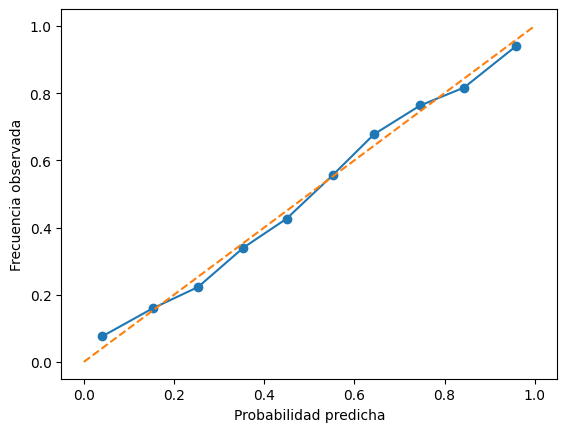

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10
)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], '--')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")
plt.show()

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    pipeline_lr,
    method='isotonic',
    cv=5
)

calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(remainder='passthrough',
                                                                    transformers=[('cat',
                                                                                   OneHotEncoder(),
                                                                                   ['series',
                                                                                    'court',
                                                                                    'surface',
                                                                                    'round']),
                                                                                  ('num',
                                                                                   StandardScaler(),
                                                                                   ['pts_diff',
                                                                                    'rank_diff',
                                                                                    'odd_diff',
                                                                                    'h2h_diff',
                                                                                    'n_matches_diff',
                                                                                    'n_tournaments_diff',
                                                                                    'n_surfaces_diff',
                                                                                    'win_rate_diff',
                                                                                    'experience_diff'])])),
                                                 ('classifier',
                                                  LogisticRegression())]),
                       method='isotonic')

In [ ]:
prob_before = pipeline_lr.predict_proba(X_test)[:,1]
prob_after = calibrated_model.predict_proba(X_test)[:,1]

print("Brier antes:",
      brier_score_loss(y_test, prob_before))

print("Brier después:",
      brier_score_loss(y_test, prob_after))

print("El modelo ya estaba bastante bien calibrado en este caso")

Brier antes: 0.1986120991177865
Brier después: 0.1983262770420428
El modelo ya estaba bastante bien calibrado en este caso


In [ ]:
# Evaluación del threshold
from sklearn.metrics import accuracy_score

probs = pipeline_lr.predict_proba(X_test)[:, 1]

threshold_metrics = []
for t in [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]:
    preds = (probs >= t).astype(int)
    threshold_metrics.append([
        t,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds)
    ])

df_threshold_metrics = pd.DataFrame(threshold_metrics, columns=["Threshold", "Accuracy", "Precision", "Recall"])
df_threshold_metrics

,Threshold,Accuracy,Precision,Recall
0,0.0,0.502875,0.502875,1.000000
1,0.1,0.542813,0.523974,0.992835
2,0.2,0.574243,0.542526,0.978201
3,0.3,0.622077,0.576154,0.939939
4,0.4,0.666156,0.623835,0.846646
5,0.5,0.691453,0.690115,0.701372
6,0.6,0.671522,0.763127,0.502896
7,0.7,0.621771,0.825721,0.314177
8,0.8,0.575086,0.879761,0.179573
9,0.9,0.543580,0.939130,0.098780


Usaremos el threshold default de 0.5 para las probabilidades base, pero solo apostaremos cuando sea la precisión mayor a 87%, es decir, con threshold de 0.8

## Saving

In [ ]:
import pickle

with open("model.pkl", "wb") as f:
  pickle.dump(pipeline_lr, f)

## Inference & Simulation

In [ ]:
# Inferencia con mismos datos de testing
real_data_test = df_atp[["Tournament", "Court", "Surface", "Player_1", "Player_2", "Winner"]].iloc[X_test.index]
prediction_test = pipeline_lr.predict(X_test)
probabilities_test = pipeline_lr.predict_proba(X_test)[:, 1]

real_data_test["Predicted"] = real_data_test["Player_1"].where(prediction_test==1, real_data_test["Player_2"])

real_data_test["Probability"] = probabilities_test
# Change probability based on which player was predicted
real_data_test.loc[real_data_test["Predicted"] == real_data_test["Player_2"], "Probability"] = 1 - real_data_test["Probability"]
real_data_test["Bet"] = (real_data_test["Probability"] >= 0.8).astype(int)

real_data_test

,Tournament,Court,Surface,Player_1,Player_2,Winner,Predicted,Probability,Bet
5323,President's Cup,Outdoor,Hard,Schuettler R.,Vacek D.,Schuettler R.,Schuettler R.,0.666399,0
22695,International Championships,Outdoor,Hard,Kunitsyn I.,Mirnyi M.,Kunitsyn I.,Kunitsyn I.,0.552362,0
45563,Memphis Open,Indoor,Hard,Darcis S.,Dzumhur D.,Dzumhur D.,Darcis S.,0.575714,0
11366,adidas International,Outdoor,Hard,Moya C.,Bogomolov A.,Moya C.,Moya C.,0.785526,0
45267,Apia International,Outdoor,Hard,Mahut N.,Bellucci T.,Mahut N.,Mahut N.,0.535212,0
...,...,...,...,...,...,...,...,...,...
33661,Estoril Open,Outdoor,Clay,Ramos A.,Phau B.,Ramos A.,Ramos A.,0.769145,0
57265,Monte Carlo Masters,Outdoor,Clay,Norrie C.,Ramos-Vinolas A.,Ramos-Vinolas A.,Norrie C.,0.558227,0
43800,Geneva Open,Outdoor,Clay,Cervantes I.,Beck A.,Cervantes I.,Cervantes I.,0.667940,0
34648,US Open,Outdoor,Hard,Ramirez-Hidalgo R.,Devvarman S.,Ramirez-Hidalgo R.,Ramirez-Hidalgo R.,0.741508,0


In [ ]:
data_bet = real_data_test[real_data_test["Bet"] == 1]
print("Porcentaje de apuestas: %.2f%%" % (real_data_test["Bet"].mean()*100))
print("Precisión de apuestas: %.2f%%"% (accuracy_score(data_bet["Winner"], data_bet["Predicted"])*100))
print("Lista de apuestas:")
data_bet

Porcentaje de apuestas: 19.59%
Precisión de apuestas: 88.03%
Lista de apuestas:


,Tournament,Court,Surface,Player_1,Player_2,Winner,Predicted,Probability,Bet
46274,Internazionali BNL d'Italia,Outdoor,Clay,Troicki V.,Napolitano S.,Troicki V.,Troicki V.,0.802562,1
52740,BNP Paribas Masters,Indoor,Hard,Djokovic N.,Moutet C.,Djokovic N.,Djokovic N.,0.995050,1
36282,Power Horse Cup,Outdoor,Clay,Ghem A.,Monaco J.,Monaco J.,Monaco J.,0.992560,1
15984,Legg Mason Classic,Outdoor,Hard,Clayton A.,Reynolds B.,Reynolds B.,Reynolds B.,0.939460,1
10412,Legg Mason Classic,Outdoor,Hard,Davydenko N.,Larose S.,Davydenko N.,Davydenko N.,0.803391,1
...,...,...,...,...,...,...,...,...,...
26179,French Open,Outdoor,Clay,Wawrinka S.,Massu N.,Wawrinka S.,Wawrinka S.,0.930789,1
15913,Generali Open,Outdoor,Clay,Melzer J.,Vemic D.,Melzer J.,Melzer J.,0.818463,1
63476,Canadian Open,Outdoor,Hard,Sinner J.,Tabilo A.,Sinner J.,Sinner J.,0.965261,1
20433,Sony Ericsson Open,Outdoor,Hard,Delic A.,Davydenko N.,Delic A.,Davydenko N.,0.898505,1


In [ ]:
from datetime import datetime

df_atp_inference = pd.read_csv("atp_tennis.csv")
df_atp_inference["Date"] = df_atp_inference["Date"].astype("datetime64[ns]")
df_atp_inference = df_atp_inference.sort_values(by="Date")

inference_player_base_stats = pd.concat([
    df_atp_inference[["Date", "Player_1", "Pts_1", "Rank_1", "Odd_1"]].rename(columns={"Player_1": "Player", "Pts_1": "Pts", "Rank_1": "Rank", "Odd_1": "Odd"}),
    df_atp_inference[["Date", "Player_2", "Pts_2", "Rank_2", "Odd_2"]].rename(columns={"Player_2": "Player", "Pts_2": "Pts", "Rank_2": "Rank", "Odd_2": "Odd"})
]).sort_values(by=["Date"])

def model_inference_callback(series, court, surface, round, p1, p2):

  curr_date = datetime.now().strftime("%Y-%m-%d")

  empty_row = pd.DataFrame([{}], columns=df_atp_inference.columns)
  df_temp = pd.concat([df_atp_inference, empty_row], ignore_index=True)
  last_row = len(df_temp)-1
  df_temp.loc[last_row, "Date"] = curr_date
  df_temp.loc[last_row, "Series"] = series
  df_temp.loc[last_row, "Court"] = court
  df_temp.loc[last_row, "Round"] = round
  df_temp.loc[last_row, "Surface"] = surface
  df_temp.loc[last_row, "Player_1"] = p1
  df_temp.loc[last_row, "Player_2"] = p2
  # Add Rank_1	Rank_2	Pts_1	Pts_2	Odd_1	Odd_2 based on last registry
  df_temp.loc[last_row, "Rank_1"] = inference_player_base_stats[inference_player_base_stats["Player"] == p1].iloc[-1]["Rank"]
  df_temp.loc[last_row, "Rank_2"] = inference_player_base_stats[inference_player_base_stats["Player"] == p2].iloc[-1]["Rank"]
  df_temp.loc[last_row, "Pts_1"] = inference_player_base_stats[inference_player_base_stats["Player"] == p1].iloc[-1]["Pts"]
  df_temp.loc[last_row, "Pts_2"] = inference_player_base_stats[inference_player_base_stats["Player"] == p2].iloc[-1]["Pts"]
  df_temp.loc[last_row, "Odd_1"] = inference_player_base_stats[inference_player_base_stats["Player"] == p1].iloc[-1]["Odd"]
  df_temp.loc[last_row, "Odd_2"] = inference_player_base_stats[inference_player_base_stats["Player"] == p2].iloc[-1]["Odd"]

  df_temp["Pts Diff"] = df_temp["Pts_1"] - df_temp["Pts_2"]
  df_temp["Rank Diff"] = df_temp["Rank_1"] - df_temp["Rank_2"]
  df_temp["Odd Diff"] = df_temp["Odd_1"] - df_temp["Odd_2"]

  df_temp = pd.concat([
      df_temp,
      compute_hist_features(df_temp)
  ], axis=1)

  df_temp = df_temp[[
    'Series', 'Court', 'Surface', 'Round',
    'Pts Diff', 'Rank Diff', 'Odd Diff', 'h2h_diff',
    'n_matches_diff', 'n_tournaments_diff', 'n_surfaces_diff',
    'win_rate_diff', 'experience_diff'
  ]]
  df_temp.columns = df_temp.columns.str.lower()
  df_temp.columns = df_temp.columns.str.replace(" ", "_")

  # Model inference
  prob = pipeline_lr.predict_proba(df_temp.iloc[[-1]])[:, 1][0]

  return prob

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

import warnings

warnings.filterwarnings("ignore")

# Reference lists
series = sorted(df_atp["Series"].unique())
courts = sorted(df_atp["Court"].unique())
surfaces = sorted(df_atp["Surface"].unique())
players = sorted(
    set(df_atp["Player_1"]).union(df_atp["Player_2"])
)

# Widgets
series_dd = widgets.Dropdown(
    options=series,
    description="Series:",
    layout=widgets.Layout(width="400px")
)

court_dd = widgets.Dropdown(
    options=courts,
    description="Court:",
    layout=widgets.Layout(width="400px")
)

surface_dd = widgets.Dropdown(
    options=surfaces,
    description="Surface:",
    layout=widgets.Layout(width="400px")
)

round_dd = widgets.Dropdown(
    options=sorted(df_atp["Round"].unique()),
    description="Round:",
    layout=widgets.Layout(width="400px")
)

player1_dd = widgets.Dropdown(
    options=players,
    description="Player 1:",
    layout=widgets.Layout(width="400px")
)

player2_dd = widgets.Dropdown(
    options=players,
    description="Player 2:",
    layout=widgets.Layout(width="400px")
)

button = widgets.Button(
    description="Predict Match",
    button_style="success",
    icon="check"
)

output = widgets.Output()

def predict_match(b):
    with output:
        clear_output()

        p1 = player1_dd.value
        p2 = player2_dd.value

        if p1 == p2:
            print("Players must be different.")
            return

        series = series_dd.value
        court = court_dd.value
        surface = surface_dd.value
        round = round_dd.value

        print("Calulating.. please wait")

        prob = model_inference_callback(series, court, surface, round, p1, p2)

        print(f"{p1}: {prob:.1%}")
        print(f"{p2}: {1-prob:.1%}")

        if prob >= 0.80:
            print("\n✅ Betting opportunity")
        else:
            print("\n⚠️ Confidence below threshold")

button.on_click(predict_match)

ui = widgets.VBox([
    widgets.HTML("<h2>🎾 Tennis Match Predictor</h2>"),
    series_dd,
    court_dd,
    surface_dd,
    round_dd,
    player1_dd,
    player2_dd,
    button,
    output
])

display(ui)